In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import auc, accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_score, recall_score, f1_score
from scipy.stats import ks_2samp
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


In [3]:
iris=load_iris()

In [4]:
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [5]:
X=pd.DataFrame(iris['data'],columns=['sepal length in cm','sepal width in cm','petal length in cm','petal width in cm'])
X.head()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
X.describe()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sepal length in cm  150 non-null    float64
 1   sepal width in cm   150 non-null    float64
 2   petal length in cm  150 non-null    float64
 3   petal width in cm   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [8]:
X.isnull().sum()

sepal length in cm    0
sepal width in cm     0
petal length in cm    0
petal width in cm     0
dtype: int64

In [9]:
y=pd.DataFrame(iris['target'],columns=['Class'])
y.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [10]:
y.value_counts()

Class
0        50
1        50
2        50
Name: count, dtype: int64

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)
print("Shape of X- Train: ",X_train.shape)
print("Shape of X- Test: ",X_test.shape)
print("Shape of y- Train: ",y_train.shape)
print("Shape of y- Test: ",y_test.shape)

Shape of X- Train:  (120, 4)
Shape of X- Test:  (30, 4)
Shape of y- Train:  (120, 1)
Shape of y- Test:  (30, 1)


### Full Decision Tree

In [12]:
Simple_Dtreeclassifier=DecisionTreeClassifier()
Simple_Dtreeclassifier.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [13]:
x_pred_Simple_Dtreeclassifier = Simple_Dtreeclassifier.predict(X_train)

print("========== Train Metrics ==========")
print("Train Accuracy is: ",accuracy_score(x_pred_Simple_Dtreeclassifier,y_train))
print(classification_report(x_pred_Simple_Dtreeclassifier,y_train))
print(confusion_matrix(x_pred_Simple_Dtreeclassifier,y_train))


y_pred_Simple_Dtreeclassifier = Simple_Dtreeclassifier.predict(X_test)
print("========== Test Metrics ==========")
print("Test Accuracy is: ",accuracy_score(y_pred_Simple_Dtreeclassifier,y_test))
print(classification_report(y_pred_Simple_Dtreeclassifier,y_test))
print(confusion_matrix(y_pred_Simple_Dtreeclassifier,y_test))

========== Train Metrics ==========
Train Accuracy is:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        43

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

[[40  0  0]
 [ 0 37  0]
 [ 0  0 43]]
========== Test Metrics ==========
Test Accuracy is:  0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.92      1.00      0.96        12
           2       1.00      0.88      0.93         8

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30

[[10  0  0]
 [ 0 12  0]
 [ 0  1  7]]


In [14]:

def get_model_metrics(model, X_train, y_train, X_test, y_test, model_name, best_params=None):
    # Convert y to 1D arrays
    y_train = np.ravel(y_train)
    y_test = np.ravel(y_test)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities
    y_train_prob = model.predict_proba(X_train)
    y_test_prob = model.predict_proba(X_test)

    # Number of classes
    n_classes = len(model.classes_)

    # Accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Precision / Recall / F1
    if n_classes == 2:
        precision = precision_score(y_test, y_test_pred, average='binary', zero_division=0)
        recall = recall_score(y_test, y_test_pred, average='binary', zero_division=0)
        f1 = f1_score(y_test, y_test_pred, average='binary', zero_division=0)
    else:
        precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

    # AUC / GINI / KS
    if n_classes == 2:
        train_auc = roc_auc_score(y_train, y_train_prob[:, 1])
        test_auc = roc_auc_score(y_test, y_test_prob[:, 1])

        train_gini = 2 * train_auc - 1
        test_gini = 2 * test_auc - 1

        train_ks, _ = ks_2samp(
            y_train_prob[y_train == model.classes_[0], 1],
            y_train_prob[y_train == model.classes_[1], 1]
        )

        test_ks, _ = ks_2samp(
            y_test_prob[y_test == model.classes_[0], 1],
            y_test_prob[y_test == model.classes_[1], 1]
        )

    else:
        train_auc = roc_auc_score(y_train, y_train_prob, multi_class='ovr', average='weighted')
        test_auc = roc_auc_score(y_test, y_test_prob, multi_class='ovr', average='weighted')

        train_gini = 2 * train_auc - 1
        test_gini = 2 * test_auc - 1

        train_ks_list = []
        test_ks_list = []

        for i, cls in enumerate(model.classes_):
            train_class_probs = y_train_prob[:, i]
            test_class_probs = y_test_prob[:, i]

            train_ks_stat, _ = ks_2samp(
                train_class_probs[y_train == cls],
                train_class_probs[y_train != cls]
            )

            test_ks_stat, _ = ks_2samp(
                test_class_probs[y_test == cls],
                test_class_probs[y_test != cls]
            )

            train_ks_list.append(train_ks_stat)
            test_ks_list.append(test_ks_stat)

        train_ks = max(train_ks_list)
        test_ks = max(test_ks_list)

    return {
        "Model": model_name,
        "Train Accuracy": round(train_accuracy, 4),
        "Test Accuracy": round(test_accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "Train AUC": round(train_auc, 4),
        "Test AUC": round(test_auc, 4),
        "Train GINI": round(train_gini, 4),
        "Test GINI": round(test_gini, 4),
        "Train KS": round(train_ks, 4),
        "Test KS": round(test_ks, 4),
        "Best Params": str(best_params) if best_params else "Default"
    }

In [15]:
results = []

results.append(
    get_model_metrics(
        Simple_Dtreeclassifier,
        X_train, y_train, X_test, y_test,
        model_name="Full Decision Tree",
        best_params=None
    )
)

results_df = pd.DataFrame(results)
results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Train AUC,Test AUC,Train GINI,Test GINI,Train KS,Test KS,Best Params
0,Full Decision Tree,1.0,0.9667,0.9708,0.9667,0.9671,1.0,0.9783,1.0,0.9565,1.0,1.0,Default


[Text(0.3076923076923077, 0.9285714285714286, 'x[3] <= 0.8\ngini = 0.665\nsamples = 120\nvalue = [40, 37, 43]'),
 Text(0.23076923076923078, 0.7857142857142857, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'x[2] <= 4.75\ngini = 0.497\nsamples = 80\nvalue = [0, 37, 43]'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'x[3] <= 1.65\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6153846153846154, 0.6428571428571429, 'x[3] <= 1.75\ngini = 0.159\nsamples = 46\nvalue = [0, 4, 42]'),
 Text(0.38461538461538464, 0.5, 'x[1] <= 2.65\ngini = 0.49\nsamples = 7\nvalue = [0, 3, 4]'),
 Text(0.3076923076923077, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [0, 

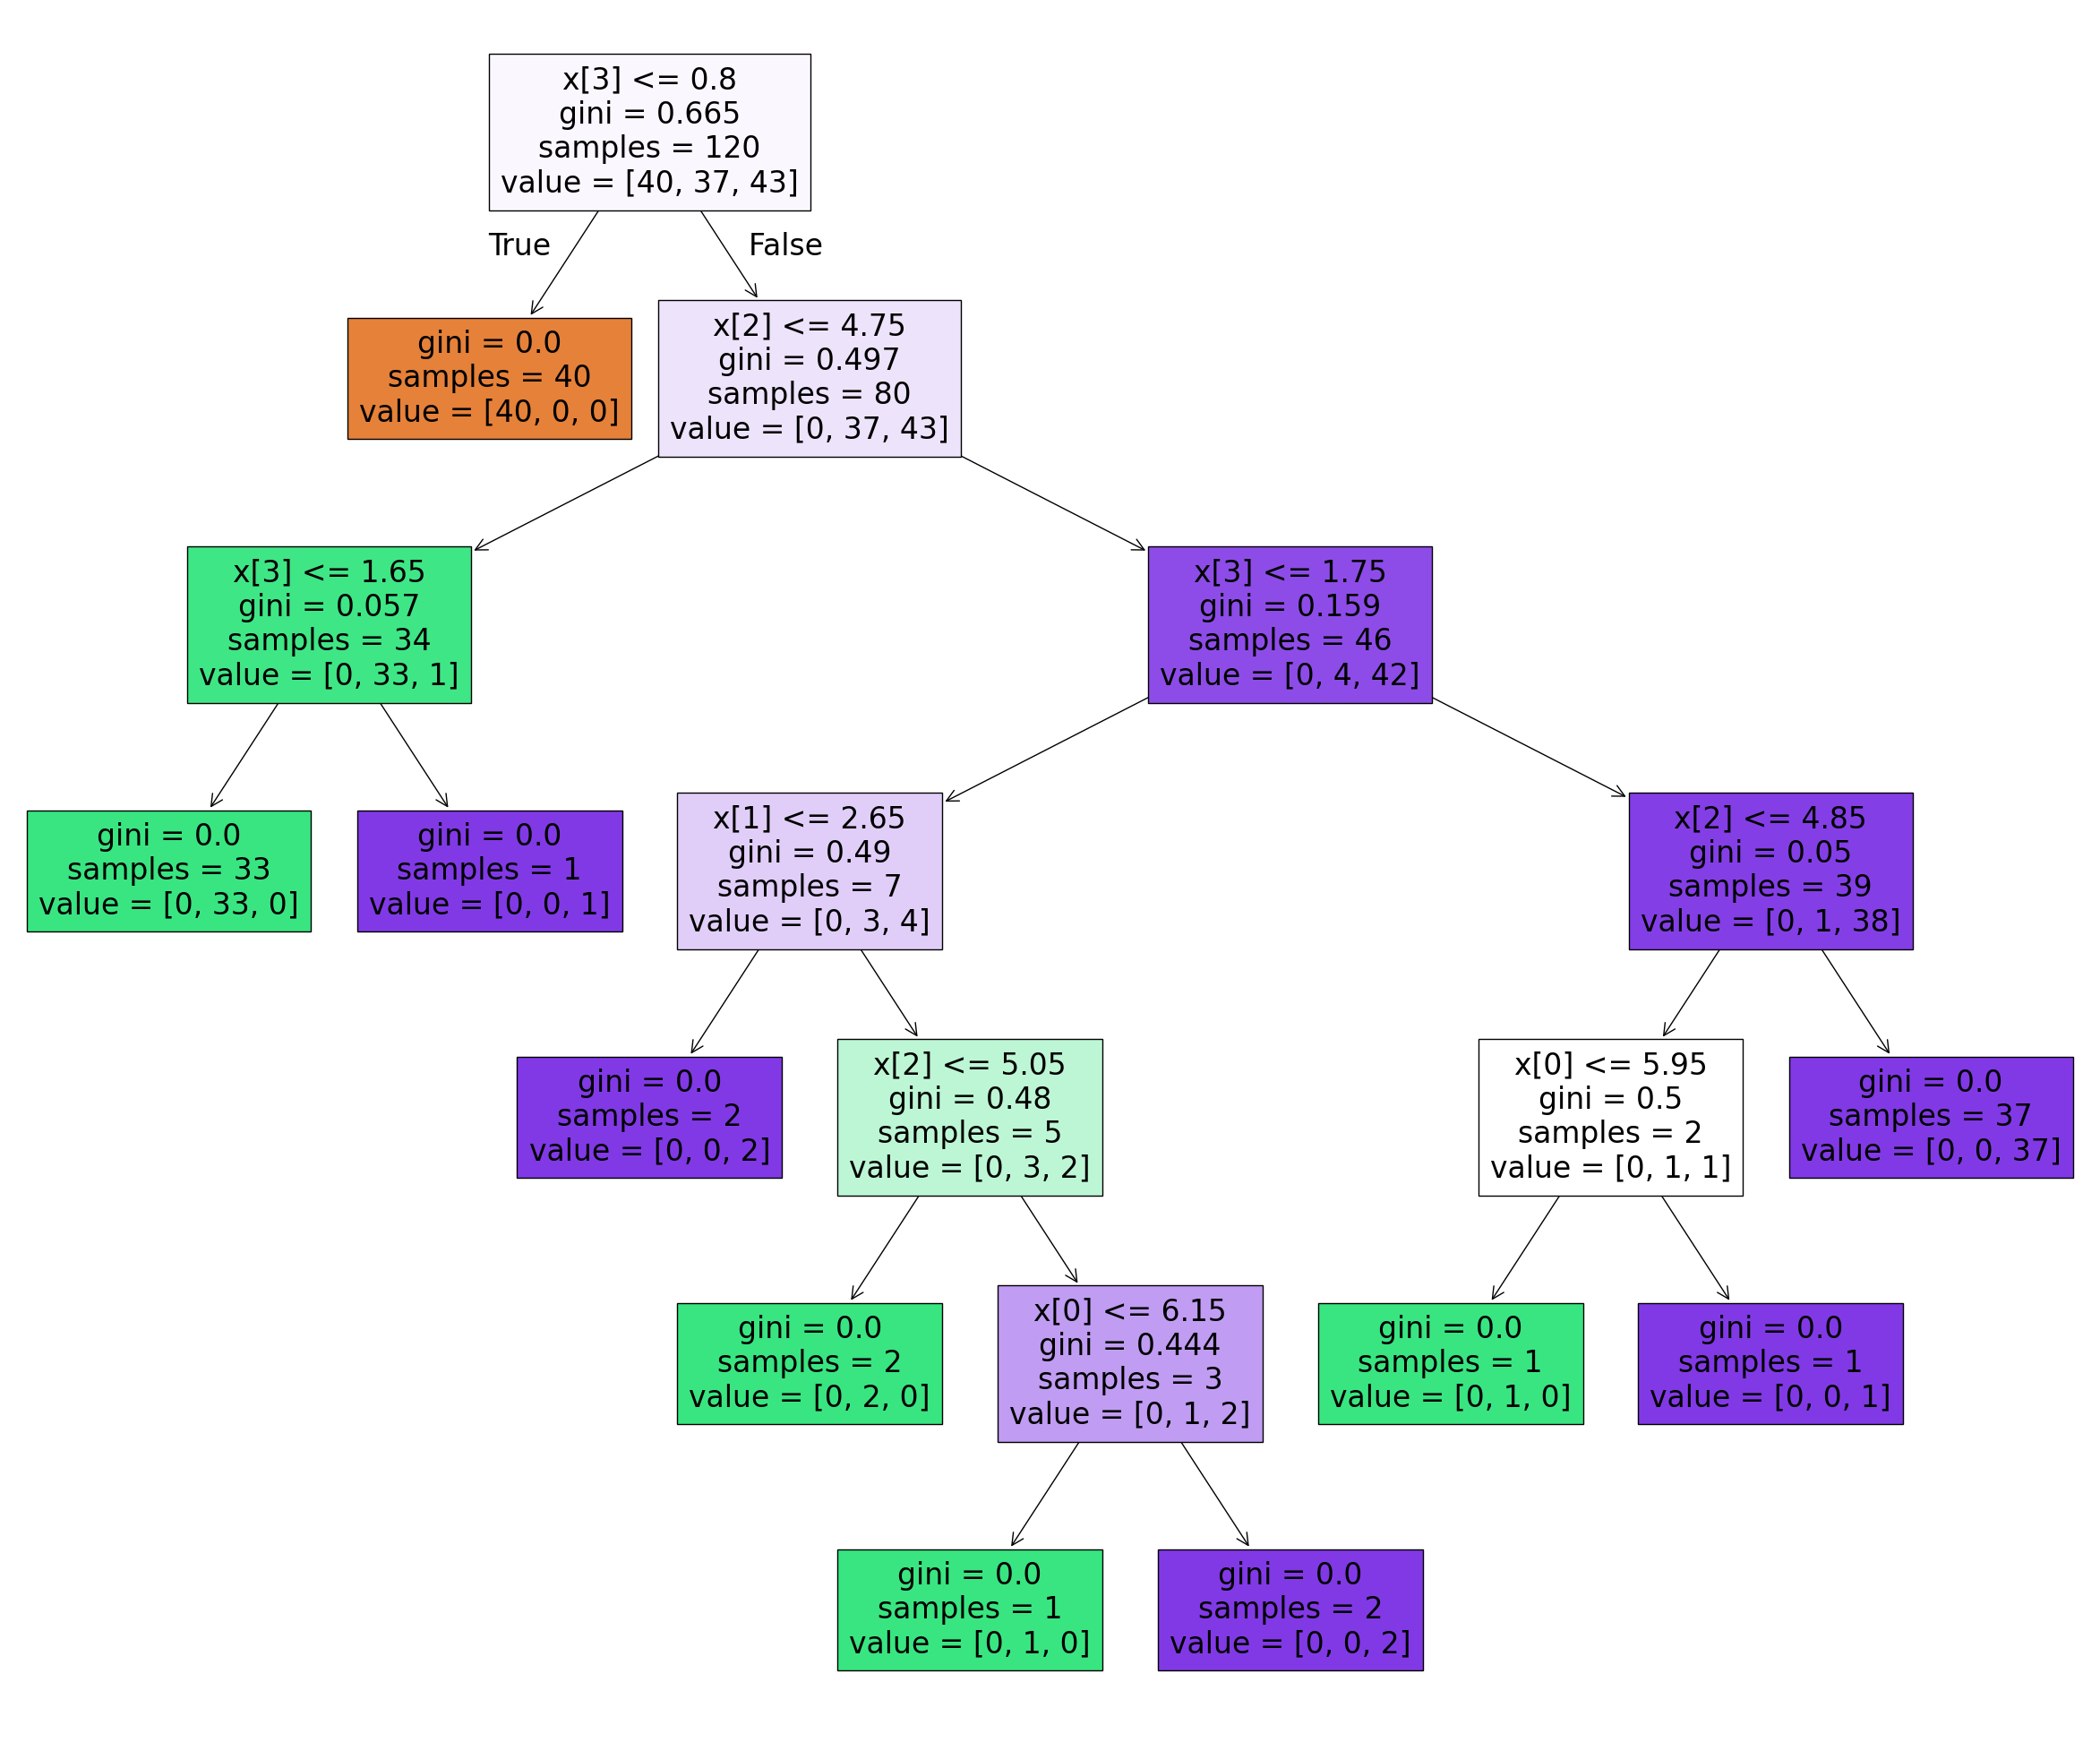

In [16]:
plt.figure(figsize=(30,25))
tree.plot_tree(Simple_Dtreeclassifier,filled=True)

## Post-Pruning
##### From the decision tree above, pruning the model at a maximum depth of 2 (particularly at the split on feature X[3]) is sufficient, as the primary class separations are already achieved in the top two levels. Further splits only capture minor variations and increase the risk of overfitting without meaningful gain in model performance.
##### At this depth:
 - The first major split (X[3] ≤ 0.8) perfectly classifies one class (pure node with Gini = 0).
 - The subsequent split captures most of the remaining structure, effectively separating the second dominant class.
 - The residual observations (third class) are relatively small and do not justify deeper splits.
##### Therefore, limiting the tree depth to 2 reduces model complexity and prevents overfitting, while still preserving the majority of the  predictive power. Deeper splits mainly capture noise and marginal improvements, which are not generalizable.

In [17]:
# Get pruning path
path = Simple_Dtreeclassifier.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print("Number of candidate alphas:", len(ccp_alphas))
print(ccp_alphas)

Number of candidate alphas: 7
[0.         0.00811966 0.00952381 0.01605882 0.01617647 0.2544123
 0.33395833]


In [18]:
# Train trees for each alpha
pruned_models = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    pruned_models.append(clf)

In [19]:
# Compare train/test accuracy and pick best alpha
alpha_results = []

for alpha, clf in zip(ccp_alphas, pruned_models):
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    alpha_results.append({
        "ccp_alpha": alpha,
        "tree_depth": clf.get_depth(),
        "n_leaves": clf.get_n_leaves(),
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy": accuracy_score(y_test, y_test_pred)
    })

alpha_results_df = pd.DataFrame(alpha_results)
alpha_results_df

,ccp_alpha,tree_depth,n_leaves,train_accuracy,test_accuracy
0,0.000000,6,10,1.000000,0.966667
1,0.008120,6,8,0.991667,0.966667
2,0.009524,3,5,0.966667,0.933333
3,0.016059,3,4,0.966667,0.933333
4,0.016176,2,3,0.958333,0.933333
5,0.254412,1,2,0.691667,0.566667
6,0.333958,0,1,0.358333,0.233333


In [20]:
# Choose the best post-pruned tree

best_row = alpha_results_df.iloc[4]

best_alpha = best_row["ccp_alpha"]
print(round(best_alpha,6))

0.016176


In [21]:
best_row

ccp_alpha         0.016176
tree_depth        2.000000
n_leaves          3.000000
train_accuracy    0.958333
test_accuracy     0.933333
Name: 4, dtype: float64

In [22]:
post_pruned_tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

post_pruned_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [23]:
x_pred_post_pruned_tree = post_pruned_tree.predict(X_train)

print("========== Train Metrics ==========")
print("Train Accuracy is: ",accuracy_score(x_pred_post_pruned_tree,y_train))
print(classification_report(x_pred_post_pruned_tree,y_train))
print(confusion_matrix(x_pred_post_pruned_tree,y_train))


y_pred_post_pruned_tree = post_pruned_tree.predict(X_test)
print("========== Test Metrics ==========")
print("Test Accuracy is: ",accuracy_score(y_pred_post_pruned_tree,y_test))
print(classification_report(y_pred_post_pruned_tree,y_test))
print(confusion_matrix(y_pred_post_pruned_tree,y_test))

========== Train Metrics ==========
Train Accuracy is:  0.9583333333333334
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.89      0.97      0.93        34
           2       0.98      0.91      0.94        46

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120

[[40  0  0]
 [ 0 33  1]
 [ 0  4 42]]
========== Test Metrics ==========
Test Accuracy is:  0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.85      1.00      0.92        11
           2       1.00      0.78      0.88         9

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

[[10  0  0]
 [ 0 11  0]
 [ 0  2  7]]


[Text(0.4, 0.8333333333333334, 'x[2] <= 2.45\ngini = 0.665\nsamples = 120\nvalue = [40, 37, 43]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 4.75\ngini = 0.497\nsamples = 80\nvalue = [0, 37, 43]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.057\nsamples = 34\nvalue = [0, 33, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.159\nsamples = 46\nvalue = [0, 4, 42]')]

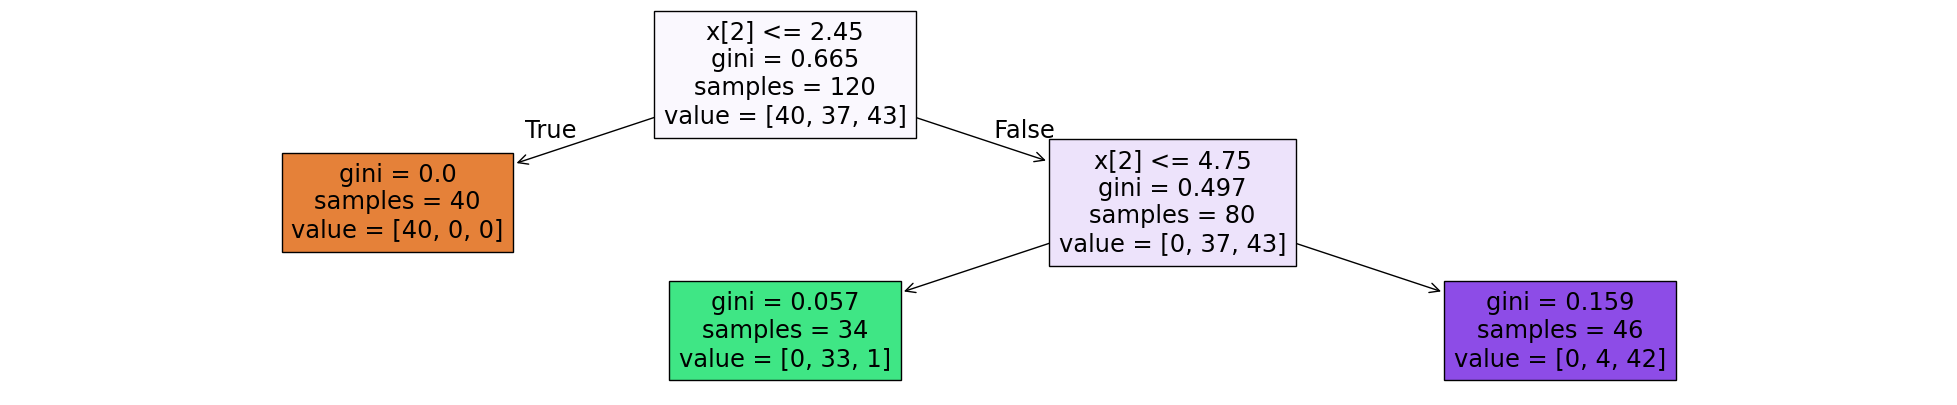

In [24]:
plt.figure(figsize=(25,5))
tree.plot_tree(post_pruned_tree,filled=True)

In [25]:
results.append(
    get_model_metrics(
        post_pruned_tree,
        X_train, y_train, X_test, y_test,
        model_name="Post-Pruned Decision Tree",
        best_params={"ccp_alpha": round(float(best_alpha), 8)}
    )
)

results_df = pd.DataFrame(results)
results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Train AUC,Test AUC,Train GINI,Test GINI,Train KS,Test KS,Best Params
0,Full Decision Tree,1.0000,0.9667,0.9708,0.9667,0.9671,1.0000,0.9783,1.0000,0.9565,1.0,1.0,Default
1,Post-Pruned Decision Tree,0.9583,0.9333,0.9481,0.9333,0.9347,0.9782,0.9761,0.9564,0.9523,1.0,1.0,{'ccp_alpha': 0.01617647}


## Decision Tree Classifier Prepruning And Hyperparameter Tuning

In [26]:
param={
    'criterion':['gini','entropy', 'log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6],
    'max_features':['auto','sqrt','log2']
}

In [27]:
cv=StratifiedKFold()
treeclassify=DecisionTreeClassifier()
grid=GridSearchCV(treeclassify,param_grid=param,cv=cv,scoring='accuracy')

In [28]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the 

In [29]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'log2',
 'splitter': 'random'}

In [30]:
grid.best_score_

np.float64(0.9583333333333334)

In [31]:
x_pred_grid = grid.predict(X_train)

print("========== Train Metrics ==========")
print("Train Accuracy is: ",accuracy_score(x_pred_grid,y_train))
print(classification_report(x_pred_grid,y_train))
print(confusion_matrix(x_pred_grid,y_train))


y_pred_grid = grid.predict(X_test)
print("========== Test Metrics ==========")
print("Test Accuracy is: ",accuracy_score(y_pred_grid,y_test))
print(classification_report(y_pred_grid,y_test))
print(confusion_matrix(y_pred_grid,y_test))

========== Train Metrics ==========
Train Accuracy is:  0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.97      0.92      0.95        39
           2       0.93      0.98      0.95        41

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120

[[40  0  0]
 [ 0 36  3]
 [ 0  1 40]]
========== Test Metrics ==========
Test Accuracy is:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         7

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0 13  0]
 [ 0  0  7]]


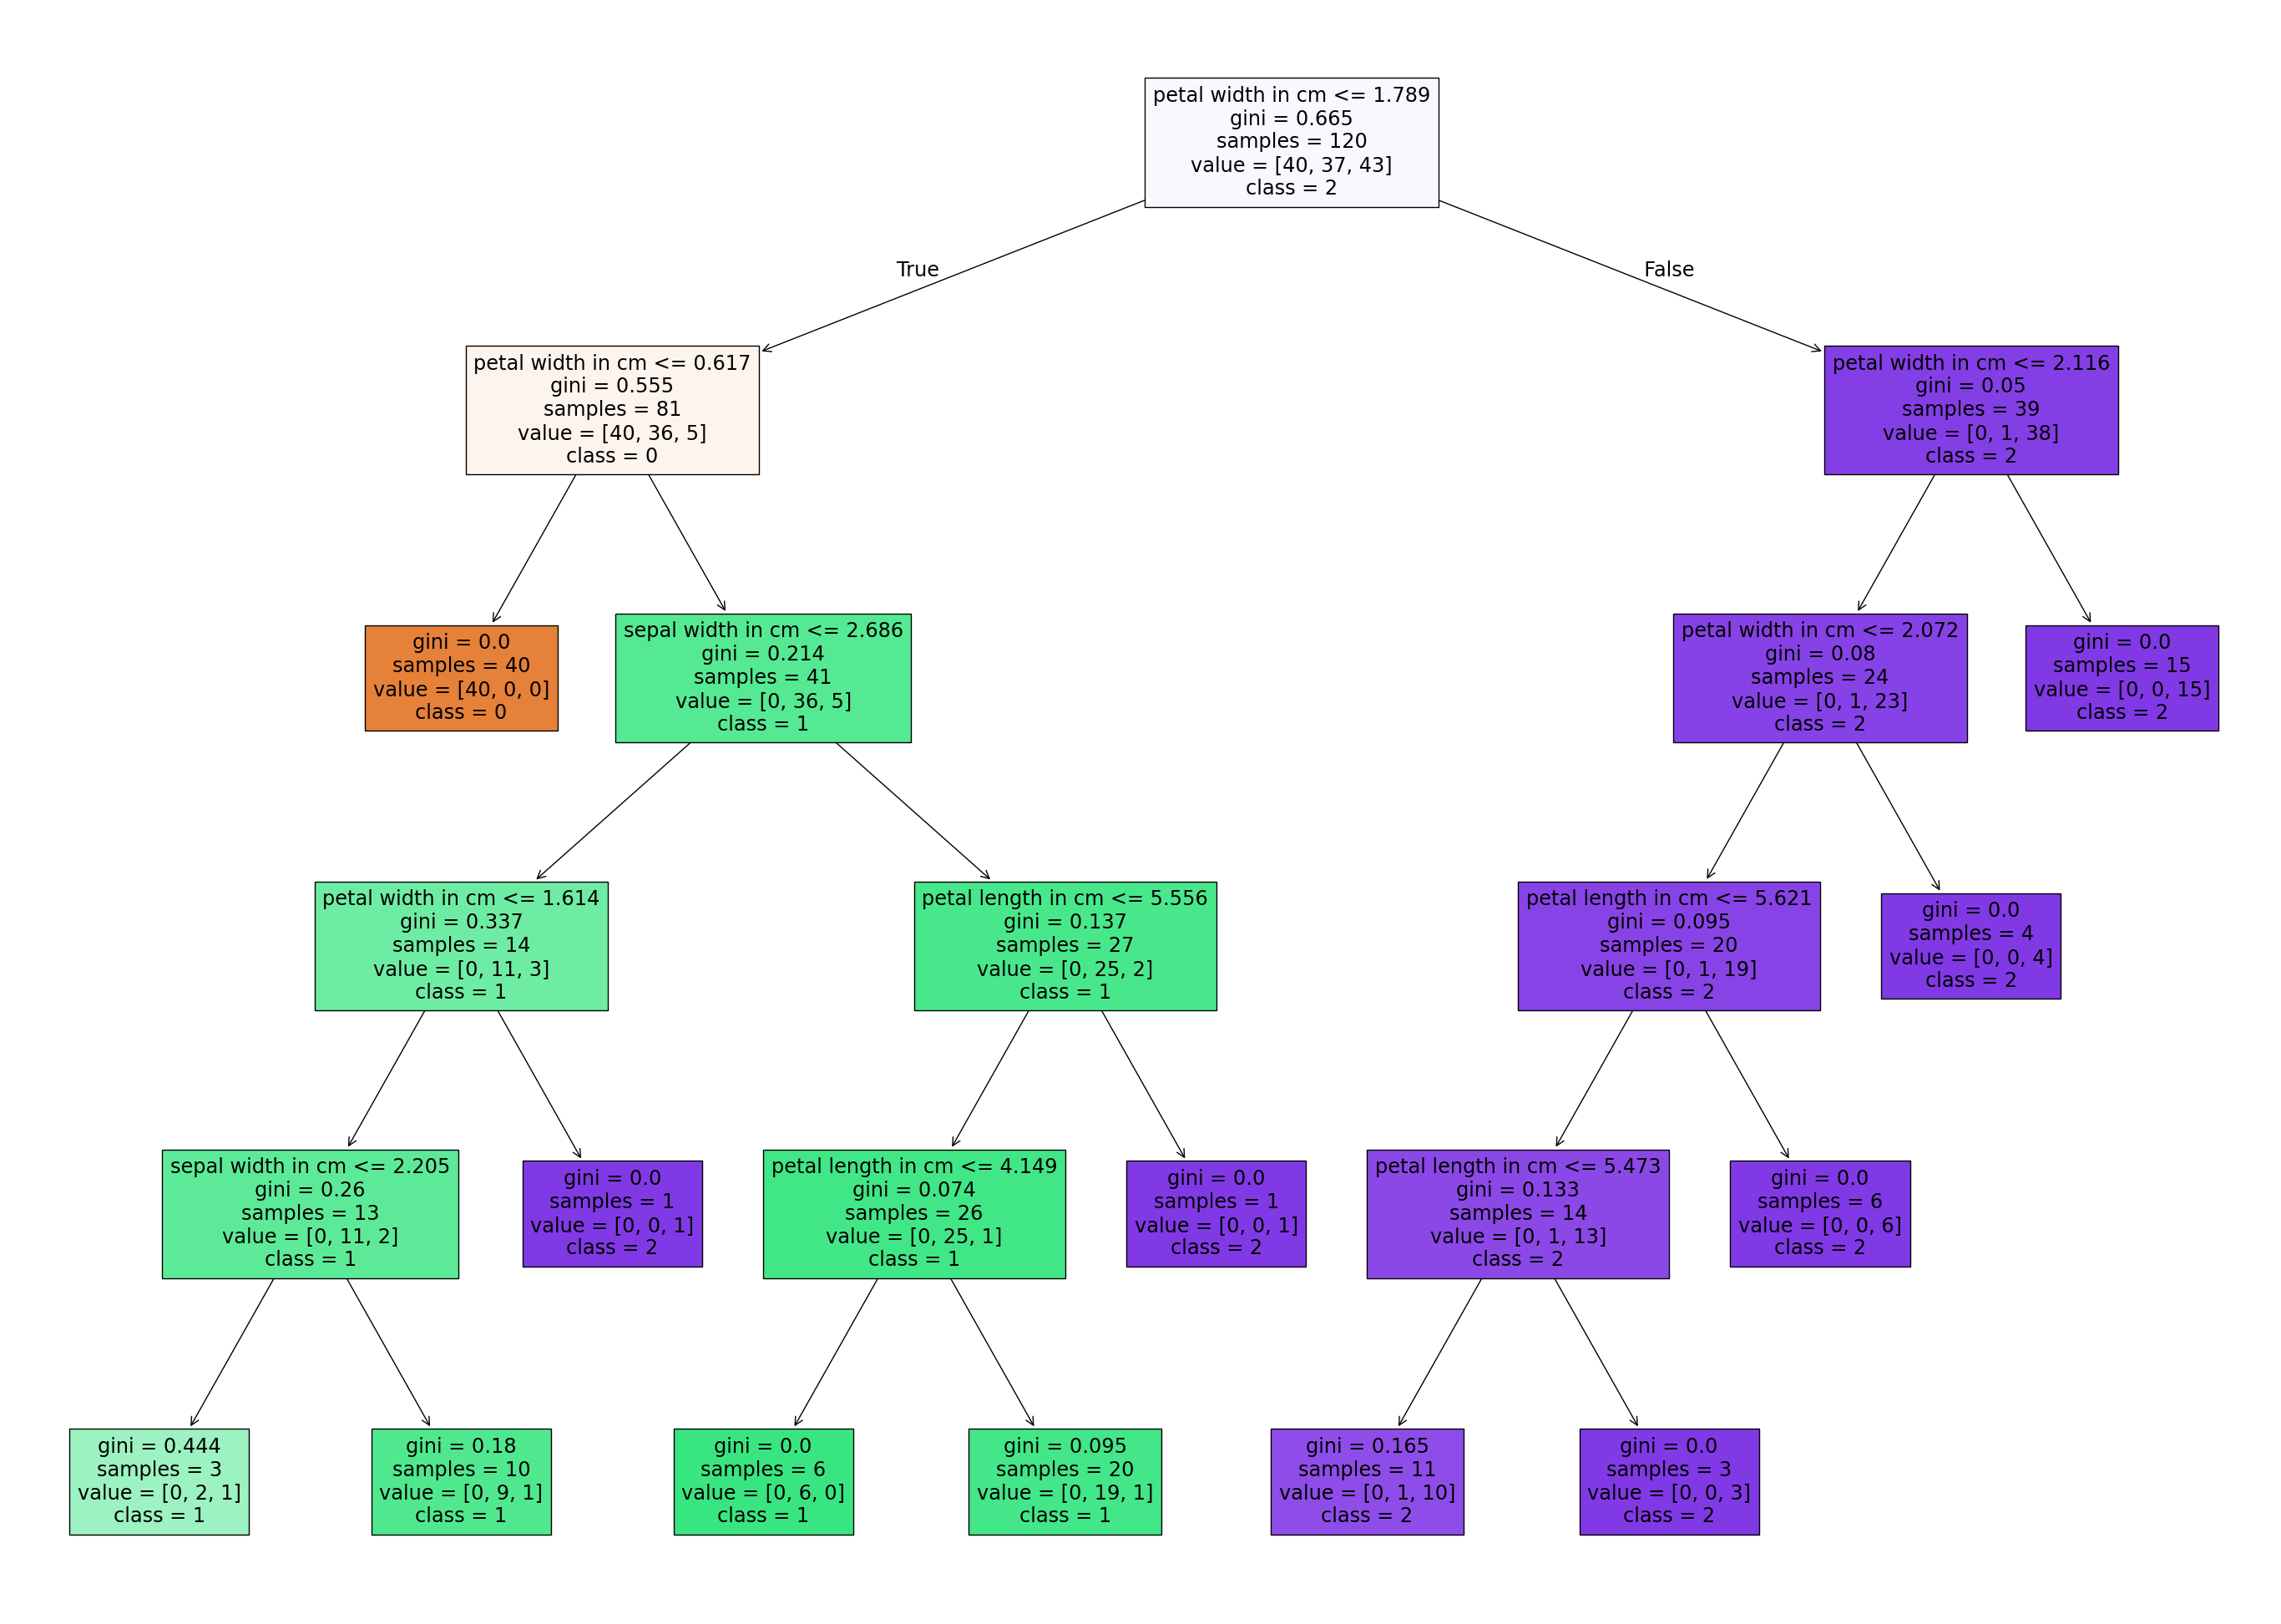

In [32]:
best_tree = grid.best_estimator_

plt.figure(figsize=(35, 25))
tree.plot_tree(
    best_tree,
    filled=True,
    feature_names=X_train.columns,
    class_names=[str(c) for c in best_tree.classes_]
)
plt.show()

In [33]:
results.append(
    get_model_metrics(
        grid,
        X_train, y_train, X_test, y_test,
        model_name="Pre-Pruned Decision Tree",
        best_params=grid.best_params_
    )
)

results_df = pd.DataFrame(results)
results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Train AUC,Test AUC,Train GINI,Test GINI,Train KS,Test KS,Best Params
0,Full Decision Tree,1.0000,0.9667,0.9708,0.9667,0.9671,1.0000,0.9783,1.0000,0.9565,1.0,1.0,Default
1,Post-Pruned Decision Tree,0.9583,0.9333,0.9481,0.9333,0.9347,0.9782,0.9761,0.9564,0.9523,1.0,1.0,{'ccp_alpha': 0.01617647}
2,Pre-Pruned Decision Tree,0.9667,1.0000,1.0000,1.0000,1.0000,0.9925,1.0000,0.9850,1.0000,1.0,1.0,"{'criterion': 'gini', 'max_depth': 5, 'max_fea..."


In [34]:
print(results_df)

                       Model  Train Accuracy  Test Accuracy  Precision  \
0         Full Decision Tree          1.0000         0.9667     0.9708   
1  Post-Pruned Decision Tree          0.9583         0.9333     0.9481   
2   Pre-Pruned Decision Tree          0.9667         1.0000     1.0000   

   Recall  F1 Score  Train AUC  Test AUC  Train GINI  Test GINI  Train KS  \
0  0.9667    0.9671     1.0000    0.9783      1.0000     0.9565       1.0   
1  0.9333    0.9347     0.9782    0.9761      0.9564     0.9523       1.0   
2  1.0000    1.0000     0.9925    1.0000      0.9850     1.0000       1.0   

   Test KS                                        Best Params  
0      1.0                                            Default  
1      1.0                          {'ccp_alpha': 0.01617647}  
2      1.0  {'criterion': 'gini', 'max_depth': 5, 'max_fea...  


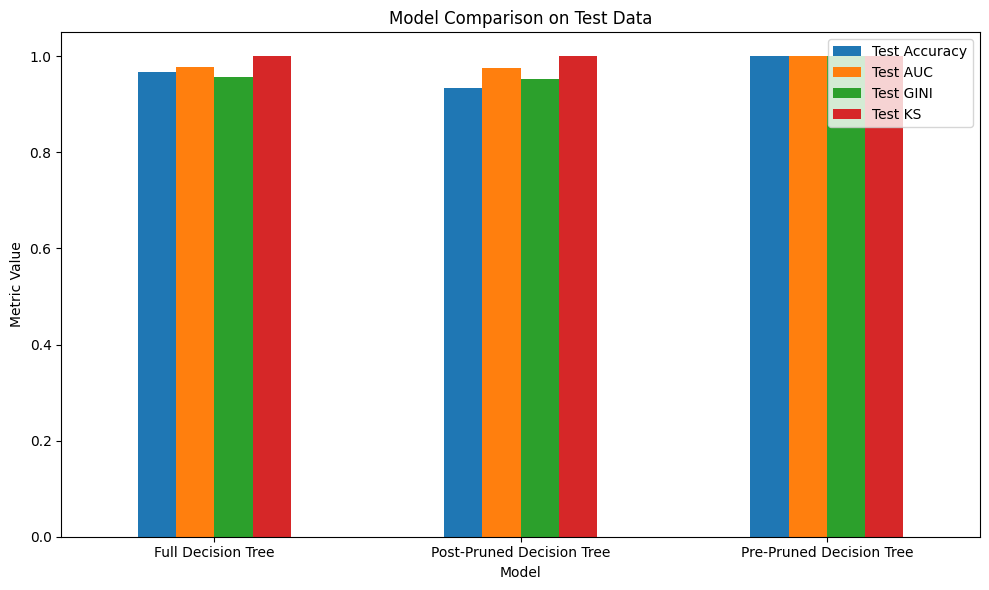

In [35]:
plot_df = results_df[["Model", "Test Accuracy", "Test AUC", "Test GINI", "Test KS"]]
plot_df = plot_df.set_index("Model")

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison on Test Data")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.legend(loc="best")
plt.tight_layout()
plt.show()